In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import argparse
import os
import re
from functools import reduce
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib

In [2]:



def process_icmp_file(file):

    with open(file) as f:
        delay_lines = f.readlines()

    delays = []
    times = []
    for line in delay_lines:
        data_math = re.match(r'.*seq=(\d+) .+time=(\d+\.?\d*) ms.*\n', line)
        if data_math:
            times.append(float(data_math[1]))
            delays.append(float(data_math[2]))

    return np.array(times), np.array(delays) / 1000.0


def get_dataset(data_dir):
    task_items = []
    servers_hist_all = []
    nodes = []

    task_items = pd.read_csv('{}/tasks.gz'.format(data_dir)).to_dict('records')
    servers_hist_all = pd.read_csv('{}/servers.gz'.format(data_dir)).to_dict('records')
    nodes = pd.read_csv('{}/nodes.gz'.format(data_dir)).to_dict('records')

    # servers_hist_mec_on = db.get_items_in_collection(collection='servers_hist', query={'mec': True}, sort=('time', 1))
    servers_hist_mec_on = [t for t in servers_hist_all if t['mec']]
    # servers_hist_control = db.get_items_in_collection(collection='servers_hist', query={'control_loop': True}, sort=('time', 1))
    servers_hist_control = [t for t in servers_hist_all if t['control_loop']]
    nodes_map = {n['ip']: n['name'] for n in nodes}
    reference_time = task_items[0]['send_time']

    return [task_items, servers_hist_all, nodes, servers_hist_mec_on, servers_hist_control, nodes_map, reference_time]


def servers_usages(servers_hist, nodes_map):
    # fig, ax = plt.subplots(1, 1)
    control_hist = [h for h in servers_hist if h['mec']]
    servers_name = np.unique([v['name'] for v in control_hist])

    normalized_times = np.array([v['time'] - control_hist[0]['time'] for v in control_hist])
    cpu_values = np.array([v['cpu'] for v in control_hist])
    servers = np.array([v['name'] for v in control_hist])

    max_time = np.max(normalized_times)
    step = 15
    curr_time = 0

    mean_cpu = []

    while(curr_time < max_time ):
        curr_time += step
        frame_indexes = (normalized_times > curr_time-15) & (normalized_times <= curr_time)
        servers_on = servers[frame_indexes]
        if len(servers_on) == 0:
            # mean_cpu.append(0)
            continue
        
        cpu_vals = cpu_values[frame_indexes]
        current_servers = np.unique(servers_on)
        cpu_usage = np.mean([np.percentile(cpu_vals[servers_on==s], 80) for s in current_servers])
        if cpu_usage >0:
            mean_cpu.append(cpu_usage)

    return np.array(mean_cpu)


    

    print(normalized_times, cpu_values, servers)
    return servers





def parse_dataset_dir(base_dir):
    datasets_names = os.listdir(base_dir)
    all_devs = []
    all_orchs = []
    all_times = []
    all_fail = []
    all_tasks = []
    all_gnd = []
    all_sats = []
    all_t = []
    all_cpu_means = []

    n_gnd = 0
    n_sats = 0
    devices = 0

    for name in datasets_names:
        if '.txt' in name:
            continue
        data_dir = '{}/{}'.format(base_dir, name)
        # datasets.append(get_dataset(db, data_dir=data_dir))
        task_items, servers_hist_all, nodes, servers_hist_mec_on, servers_hist_control, nodes_map, reference_time = get_dataset(data_dir)
        devices = int(re.search('_(\d+)dev_', name).group(1))
        n_gnd = int(re.search('_(\d+)gnd_', name).group(1))
        orch = int(re.search('_(\d+)orch_', name).group(1))
        n_sats = int(re.search('^(\d+)sats_', name).group(1))
        total_time = int(re.search('_(\d+)seconds_', name).group(1))
        # geo_type = re.search('_\d+orch_(.)', name).group(1)
        # geo_type = geo_type if geo_type in ['u', 's', 'r'] else 'None'
        # add_info = re.search('_([A-Za-z0-9]{3,7})$', name).group(1) if re.search('_([A-Za-z0-9]{3,7})$', name) is not None else 'None'

        all_devs.append(devices)
        all_orchs.append(orch)
        all_gnd.append(n_gnd)
        all_sats.append(n_sats)
        all_t.append(total_time)

        total_mec_seconds = 0
        servers_ip = np.unique([s['name'] for s in servers_hist_control if s['mec']])
        # cpu_usage = []
        for ip in servers_ip:
            s_hist_control_ip = [s for s in servers_hist_control if s['name'] == ip]
            s_hist_control_ip.sort(key=lambda v:v['time'])
            mec_ip = [g['mec'] for g in s_hist_control_ip]

            total_mec_seconds += sum([15 for m in mec_ip if m])
        server_fail_tasks = [t for t in  task_items if t['status'] == 'Fail' and not isinstance(t['server'], float)]
        server_success_tasks = [t for t in  task_items if t['status'] == 'Done']
        fail_tasks = len(server_fail_tasks) / (len(server_fail_tasks) + len(server_success_tasks))
        all_fail.append(len(server_fail_tasks))
        all_tasks.append(len([t for t in task_items if not isinstance(t['server'], float)]))
        all_times.append(total_mec_seconds)

        if name == '10sats_6gnd_100dev_1000seconds_0orch_19-05-24_07-31-56':
            print('h')

        mean_cpus = servers_usages(servers_hist_mec_on, nodes)
        all_cpu_means.append(mean_cpus)

        print('For {} gnd,  {} dev, {} orchestration got: {} seconds with fail tasks: {}, name: {}'.format(n_gnd, devices, str(orch), total_mec_seconds, fail_tasks, name))

    return {'sats': all_sats,
            'devs': all_devs, 
            'gnds': all_gnd,
            'orchs': all_orchs,
            'tasks': all_tasks,
            'fail' :all_fail, 
            'times': all_times,
            'cpu_means': all_cpu_means,
            'total_times': all_t}, len(datasets_names)

def get_parameters():
    parser = argparse.ArgumentParser()
    # parser.add_argument('--data_dirs', nargs='+', 
    #                     default=['data/sims/test'],
    #                     type=str, help='List of datasets dirs')
    parser.add_argument('--data_dirs', nargs='+', 
                    default=['data/sims/20-05-24', 'data/sims/18-05-24', 'data/sims/22-05-24'],
                    type=str, help='List of datasets dirs')    
    return parser.parse_args()


In [ ]:


matplotlib.rcParams.update({'font.size': 18})

# args  = get_parameters()
datasets = []

# fs = 14
plot_colors = list(mcolors.TABLEAU_COLORS)

orchs_dic = {0: 'Access', 7: 'Bernoulli',
4: 'Fuzzy Logic', 6: 'R Learning'}
color_index = [2, 3, 0, 1]
orchs_keys = list(orchs_dic.keys())
curves_dict = {o:[] for o in orchs_keys}
data_per_tasks = {}

data_dirs = ['../../data/sims/20-05-24', '../../data/sims/18-05-24', '../../data/sims/22-05-24']

for base_dir in data_dirs:
    data_dic, n_datasets  = parse_dataset_dir(base_dir)

    for n_dev in np.unique(data_dic['devs']):
        for n_gnd in np.unique(data_dic['gnds']):
            orchs = np.array([o for o, g, d in zip(data_dic['orchs'], data_dic['gnds'], data_dic['devs']) if g == n_gnd and d == n_dev])
            cpus = [c for c, g, d in zip(data_dic['cpu_means'], data_dic['gnds'], data_dic['devs']) if g == n_gnd and d == n_dev]

            if len(cpus) == 0:
                continue
            task_per_sec = int((n_gnd *n_dev*2) /60)
            if task_per_sec not in data_per_tasks.keys():
                data_per_tasks[task_per_sec] = (cpus, orchs)
            else:
                data_per_tasks[task_per_sec] = ( data_per_tasks[task_per_sec][0] + cpus, np.append(data_per_tasks[task_per_sec][1], orchs) )


For 11 gnd,  150 dev, 4 orchestration got: 8955 seconds with fail tasks: 0.013326247802804236, name: 10sats_11gnd_150dev_1000seconds_4orch_20-05-24_19-41-41
For 11 gnd,  150 dev, 7 orchestration got: 5085 seconds with fail tasks: 0.25901464949801645, name: 10sats_11gnd_150dev_1000seconds_7orch_20-05-24_17-43-14
For 11 gnd,  150 dev, 7 orchestration got: 5250 seconds with fail tasks: 0.2587609994927552, name: 10sats_11gnd_150dev_1000seconds_7orch_20-05-24_21-40-31
For 11 gnd,  150 dev, 7 orchestration got: 5565 seconds with fail tasks: 0.18949771689497716, name: 10sats_11gnd_150dev_1000seconds_7orch_20-05-24_19-02-06
For 11 gnd,  150 dev, 6 orchestration got: 8745 seconds with fail tasks: 0.012676228009588428, name: 10sats_11gnd_150dev_1000seconds_6orch_21-05-24_01-18-08
For 11 gnd,  150 dev, 7 orchestration got: 5370 seconds with fail tasks: 0.16175667707628136, name: 10sats_11gnd_150dev_1000seconds_7orch_20-05-24_20-21-17
For 11 gnd,  150 dev, 0 orchestration got: 9675 seconds with fa

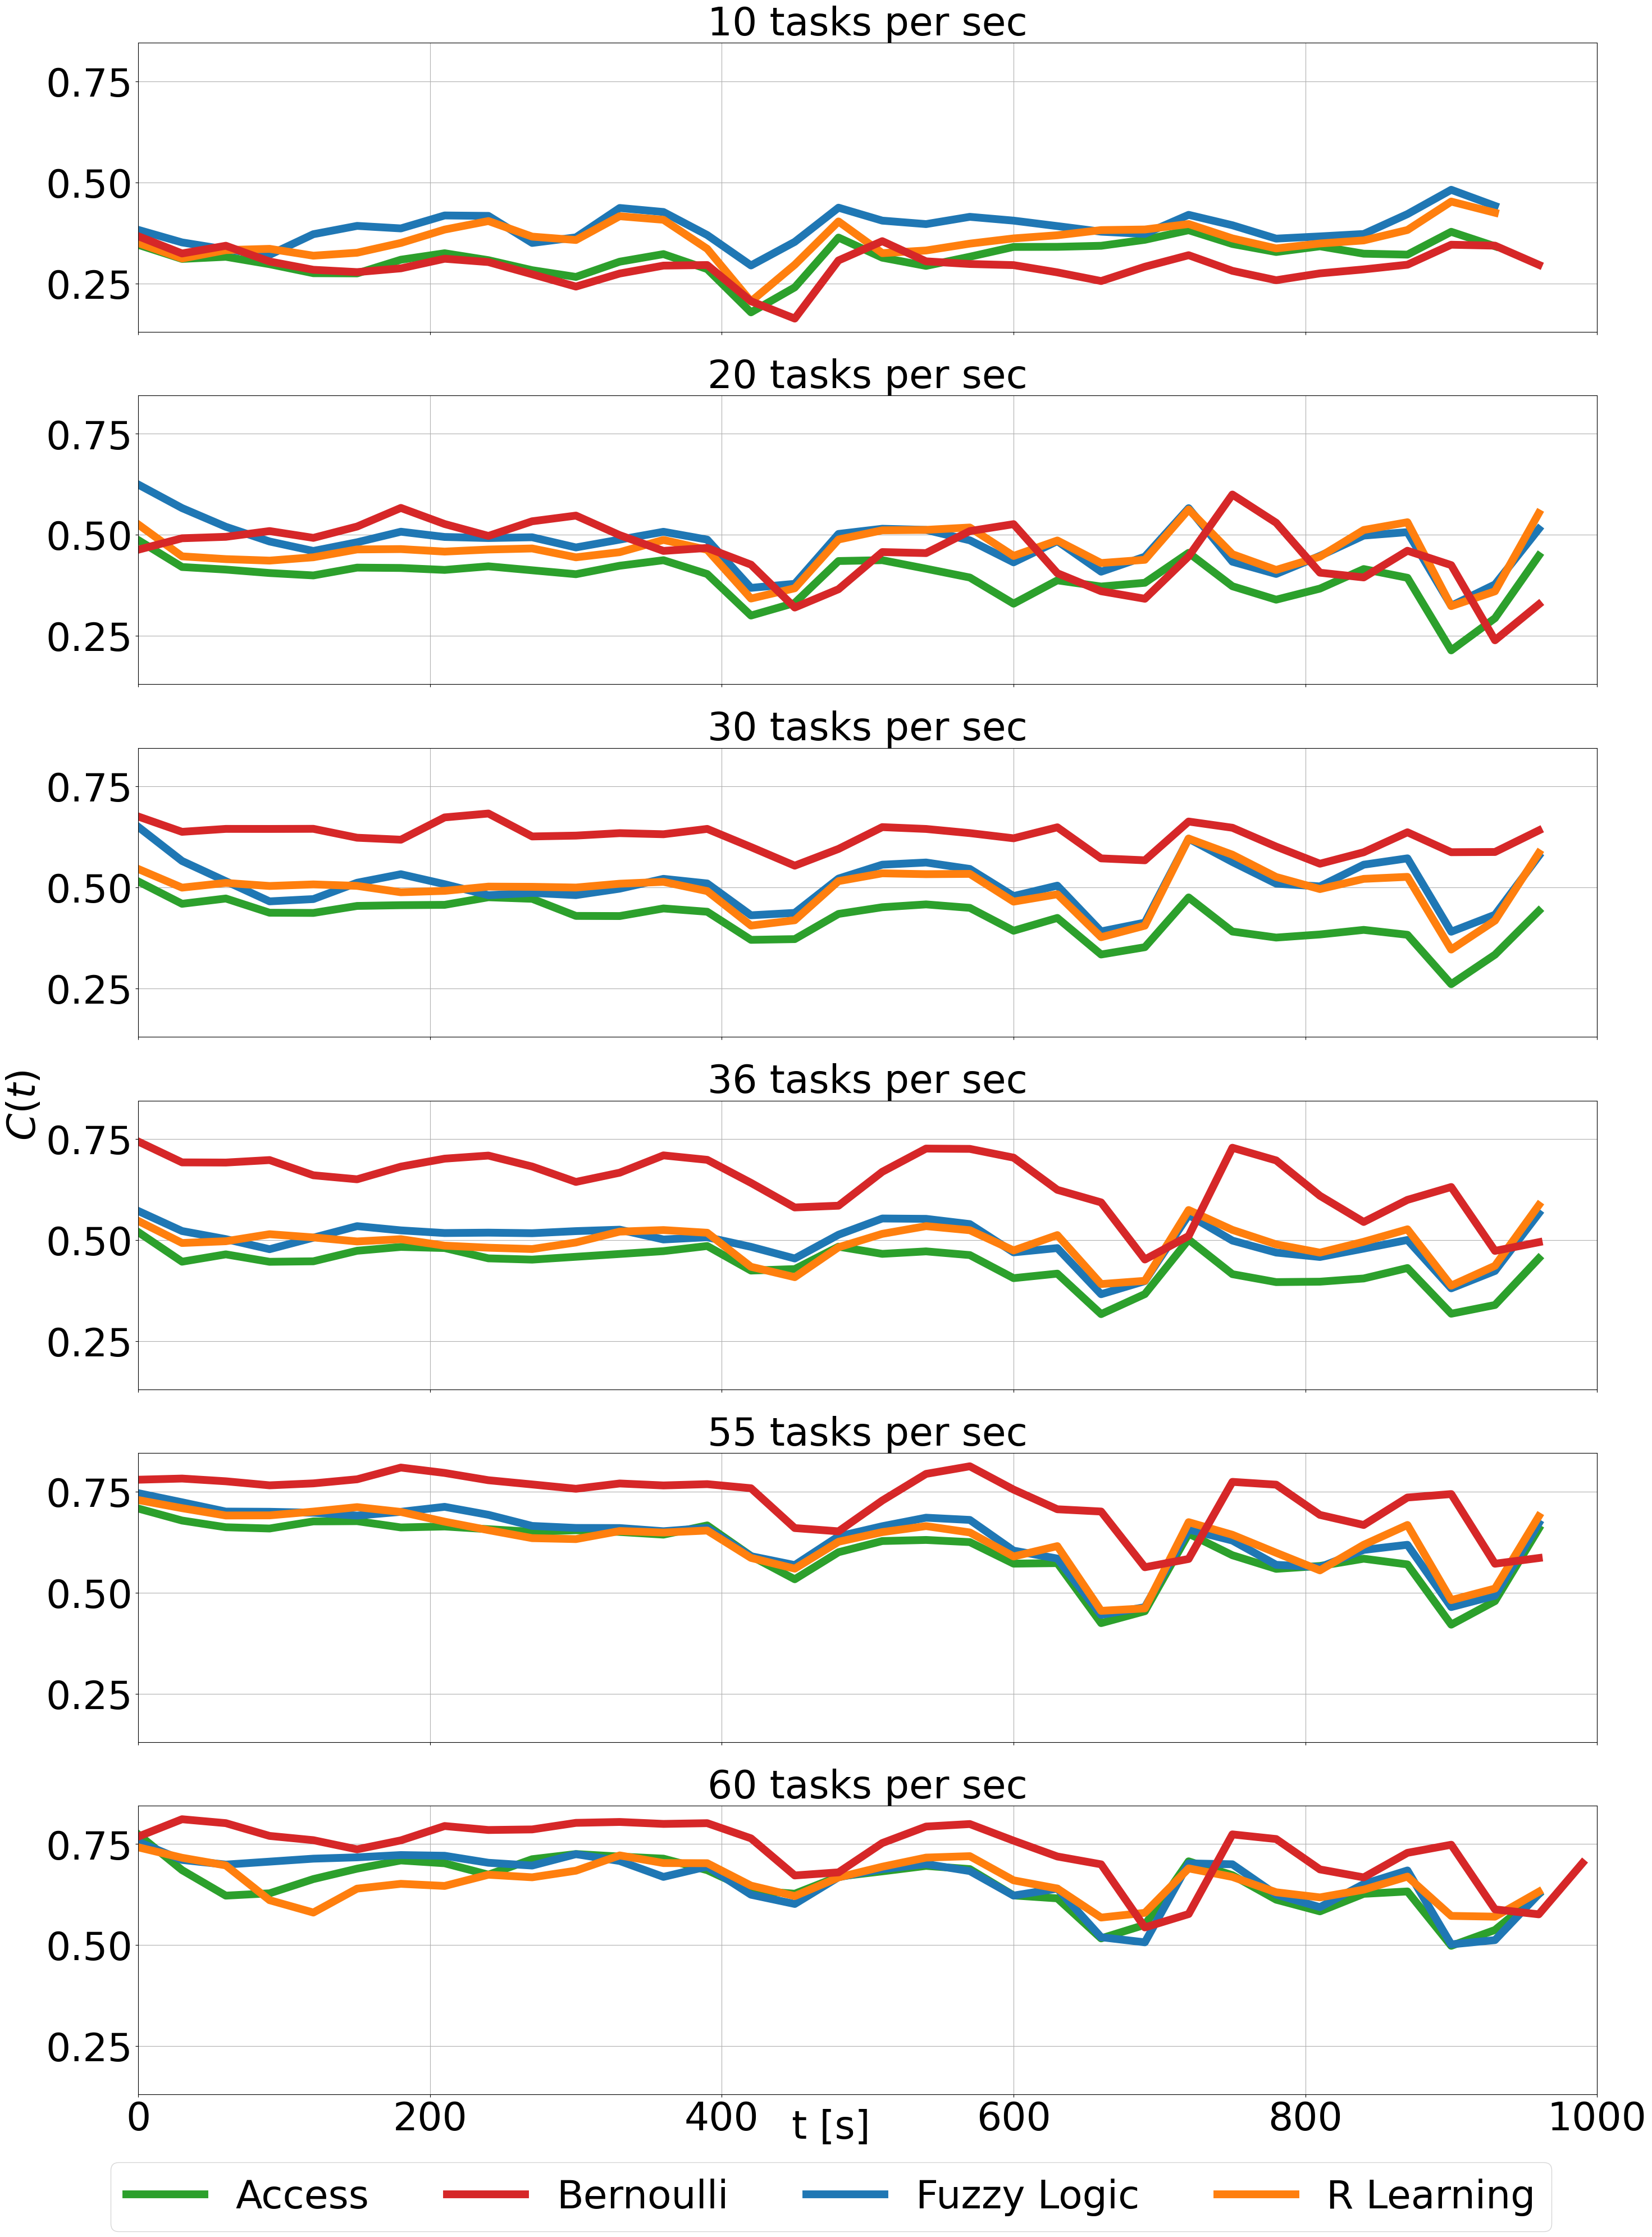

In [9]:
fsize = 50
lwidth = 10
matplotlib.rcParams.update({'font.size': fsize})


n_plots = len(data_per_tasks.keys())
fig, axs = plt.subplots(n_plots, sharex=True, sharey=True)
if n_plots == 1:
    axs = [axs]
fig.set_figwidth(30)
fig.set_figheight(40)
for i,  t in enumerate(np.sort(list(data_per_tasks.keys()))):
    ax =  axs[i]
    ax.set_title('{} tasks per sec'.format(t), fontdict={'size': fsize})
    cpus, orchs = data_per_tasks[t]
    for alg in np.unique(data_dic['orchs']):
        col = plot_colors[color_index[orchs_keys.index(alg)]]
        c_means = []
        for j, v in enumerate(orchs==alg):
            if v:
                c_means.append(cpus[j])

        max_len = max([len(m) for m in c_means])
        c_means = np.array([c if len(c) == max_len else np.concatenate([c, [np.mean(c)]*(max_len-len(c))])  for c in c_means])
        c_means = np.mean(c_means, axis=0)
        c_means = np.array([np.mean(c_means[i:i+2]) for i in range(int(len(c_means)/2))])
        # print('alg: {}, mean pc: {}'.format(alg, np.mean(c_means)))
        ax.plot([i*30 for i, v in enumerate(c_means)], c_means/100, marker='_', color=col, linewidth=lwidth)
        ax.grid()

legend_elements = [Line2D([0], [0], linestyle='-', marker=None, linewidth=lwidth, color=plot_colors[color_index[i]], label='{}'.format(orchs_dic[o]),
                    markerfacecolor=plot_colors[color_index[i]], markersize=10) for i, o in enumerate(orchs_keys)]

# legend_elements = [Line2D([0], [0], linestyle='-', marker=None, color=plot_colors[color_index[i]],  label='{}'.format(orchs[i]),
#                 markerfacecolor=plot_colors[color_index[i]], markersize=10) for i, alg in enumerate(orchs_keys)]
# fig.legend(handles=legend_elements, frameon=False)
fig.legend(handles=legend_elements, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.01))
fig.text(0.5, 0.04, 't [s]', ha='center')
fig.text(0.01, 0.5, '$C(t)$', va='center', rotation='vertical')
fig.tight_layout(pad=0.6, rect= (0.02, 0.03, 0.97, 1))
plt.xlim((0,1000))
for i,  t in enumerate(np.sort(list(data_per_tasks.keys()))):
    axs[i].grid()
# plt.show()
plt.savefig('cpus_sims.pdf')